<a href="https://colab.research.google.com/github/lamducanhkhoarubik-spec/Datathon_Contest_UITUT/blob/main/data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import os
import pandas as pd
from google.colab import userdata

# 1. Lấy token và thông tin repo
GIT_TOKEN = userdata.get('MY_GITHUB_TOKEN')
GIT_USER = "lamducanhkhoarubik-spec"
GIT_REPO = "Datathon_Contest_UITUT"

# 2. Clone bằng Token (để vượt qua lớp bảo mật Private)
repo_path = f"/content/{GIT_REPO}"

if not os.path.exists(repo_path):
    # Dùng f-string để chèn token vào link clone
    !git clone https://{GIT_TOKEN}@github.com/{GIT_USER}/{GIT_REPO}.git
else:
    print("✅ Repo đã tồn tại, đang cập nhật code mới nhất...")
    %cd {repo_path}
    !git pull
    %cd /content

# 3. Đường dẫn đến thư mục Data (Check lại chữ 'Data' hay 'data' cho đúng nhé)
path = f"{repo_path}/Data"

if os.path.exists(path):
    files = os.listdir(path)
    for file in files:
        if file.endswith('.csv'):
            file_name = os.path.splitext(file)[0]
            var_name = f"df_{file_name.replace(' ', '_')}"
            full_path = os.path.join(path, file)
            globals()[var_name] = pd.read_csv(full_path)
            print(f"✅ Đã nạp: {var_name}")
else:
    print(f"❌ Không tìm thấy thư mục: {path}. Ông kiểm tra lại tên folder trên GitHub có viết hoa hay không nha!")

✅ Repo đã tồn tại, đang cập nhật code mới nhất...
/content/Datathon_Contest_UITUT
Already up to date.
/content
✅ Đã nạp: df_sales


/tmp/ipykernel_5456/263428623.py:32: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  globals()[var_name] = pd.read_csv(full_path)


✅ Đã nạp: df_order_items
✅ Đã nạp: df_web_traffic
✅ Đã nạp: df_promotions
✅ Đã nạp: df_payments
✅ Đã nạp: df_sample_submission
✅ Đã nạp: df_geography
✅ Đã nạp: df_reviews
✅ Đã nạp: df_customers
✅ Đã nạp: df_inventory
✅ Đã nạp: df_returns
✅ Đã nạp: df_shipments
✅ Đã nạp: df_products
✅ Đã nạp: df_orders


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df_customers

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search
...,...,...,...,...,...,...,...
121925,157556,59936,Vung Tau,2016-03-03,Female,18-24,direct
121926,157557,59936,Vung Tau,2021-05-11,Female,45-54,social_media
121927,157558,59936,Vung Tau,2017-02-27,Female,25-34,referral
121928,157561,59937,Buon Ma Thuot,2018-10-15,Non-binary,45-54,paid_search


In [31]:
def check_missing_values_globals():
    # Lọc các biến trong môi trường bắt đầu bằng 'df_'
    all_vars = {k: v for k, v in globals().items() if k.startswith('df_') and isinstance(v, pd.DataFrame)}

    if not all_vars:
        print("Không tìm thấy DataFrame nào có tên bắt đầu bằng 'df_'")
        return

    for name, df in all_vars.items():
        print(f"--- Kiểm tra {name} ---")
        null_info = df.isna().sum()
        print(null_info)
        print("-" * 25)

# Chạy hàm
check_missing_values_globals()

--- Kiểm tra df_sales ---
Date       0
Revenue    0
COGS       0
dtype: int64
-------------------------
--- Kiểm tra df_order_items ---
order_id                0
product_id              0
quantity                0
unit_price              0
discount_amount         0
promo_id           438353
promo_id_2         714463
dtype: int64
-------------------------
--- Kiểm tra df_web_traffic ---
date                        0
sessions                    0
unique_visitors             0
page_views                  0
bounce_rate                 0
avg_session_duration_sec    0
traffic_source              0
dtype: int64
-------------------------
--- Kiểm tra df_promotions ---
promo_id                0
promo_name              0
promo_type              0
discount_value          0
start_date              0
end_date                0
applicable_category    40
promo_channel           0
stackable_flag          0
min_order_value         0
dtype: int64
-------------------------
--- Kiểm tra df_payments ---
ord

In [32]:
def check_duplicates_globals():
    all_dfs = {k: v for k, v in globals().items() if k.startswith('df_') and isinstance(v, pd.DataFrame)}

    if not all_dfs:
        print("Không tìm thấy DataFrame nào!")
        return

    for name, df in all_dfs.items():
        dup_count = df.duplicated().sum()
        if dup_count > 0:
            print(f"⚠️ Bảng [{name}] có {dup_count} dòng trùng lặp.")
        else:
            print(f"✅ Bảng [{name}] sạch sẽ (0 trùng lặp).")

# Sử dụng
check_duplicates_globals()

✅ Bảng [df_sales] sạch sẽ (0 trùng lặp).
✅ Bảng [df_order_items] sạch sẽ (0 trùng lặp).
✅ Bảng [df_web_traffic] sạch sẽ (0 trùng lặp).
✅ Bảng [df_promotions] sạch sẽ (0 trùng lặp).
✅ Bảng [df_payments] sạch sẽ (0 trùng lặp).
✅ Bảng [df_sample_submission] sạch sẽ (0 trùng lặp).
✅ Bảng [df_geography] sạch sẽ (0 trùng lặp).
✅ Bảng [df_reviews] sạch sẽ (0 trùng lặp).
✅ Bảng [df_customers] sạch sẽ (0 trùng lặp).
✅ Bảng [df_inventory] sạch sẽ (0 trùng lặp).
✅ Bảng [df_returns] sạch sẽ (0 trùng lặp).
✅ Bảng [df_shipments] sạch sẽ (0 trùng lặp).
✅ Bảng [df_products] sạch sẽ (0 trùng lặp).
✅ Bảng [df_orders] sạch sẽ (0 trùng lặp).
✅ Bảng [df_final_report] sạch sẽ (0 trùng lặp).
✅ Bảng [df_duplicate_ids] sạch sẽ (0 trùng lặp).
✅ Bảng [df_median_gap] sạch sẽ (0 trùng lặp).


In [33]:
import pandas as pd

def create_data_health_report():
    # 1. Lấy danh sách các DataFrame đang có trong bộ nhớ (biến bắt đầu bằng df_)
    all_dfs = {k: v for k, v in globals().items() if k.startswith('df_') and isinstance(v, pd.DataFrame)}

    report_data = []

    for name, df in all_dfs.items():
        # Tính toán các thông số
        total_rows = len(df)
        total_cols = len(df.columns)
        null_count = df.isnull().sum().sum() # Tổng số ô bị trống
        nan_count = df.isna().sum().sum()     # (Trong pandas null/nan là 1, nhưng ta cứ tính tổng)
        duplicate_count = df.duplicated().sum() # Số dòng trùng lặp hoàn toàn

        # Tính % dữ liệu bị thiếu
        total_cells = total_rows * total_cols
        missing_rate = (null_count / total_cells) * 100 if total_cells > 0 else 0

        # Lưu vào list
        report_data.append({
            'Table Name': name,
            'Total Rows': total_rows,
            'Total Cols': total_cols,
            'Total Null/NaN': null_count,
            'Duplicates': duplicate_count,
            'Missing Rate (%)': round(missing_rate, 2),
            'Memory Usage': f"{df.memory_usage(deep=True).sum() / 1024:.2f} KB"
        })

    # 2. Tạo DataFrame từ list kết quả
    health_report = pd.DataFrame(report_data)
    return health_report

# Chạy và hiển thị bảng báo cáo
df_final_report = create_data_health_report()
print("--- BẢNG TỔNG HỢP CHẤT LƯỢNG DỮ LIỆU ---")
print(df_final_report.to_markdown(index=False)) # Dùng to_markdown để in ra bảng đẹp mắt

--- BẢNG TỔNG HỢP CHẤT LƯỢNG DỮ LIỆU ---
| Table Name           |   Total Rows |   Total Cols |   Total Null/NaN |   Duplicates |   Missing Rate (%) | Memory Usage   |
|:---------------------|-------------:|-------------:|-----------------:|-------------:|-------------------:|:---------------|
| df_sales             |         3833 |            3 |                0 |            0 |               0    | 280.87 KB      |
| df_order_items       |       714669 |            7 |          1152816 |            0 |              23.04 | 79874.81 KB    |
| df_web_traffic       |         3652 |            7 |                0 |            0 |               0    | 570.08 KB      |
| df_promotions        |           50 |           10 |               40 |            0 |               8    | 20.68 KB       |
| df_payments          |       646945 |            4 |                0 |            0 |               0    | 51777.06 KB    |
| df_sample_submission |          548 |            3 |                

/tmp/ipykernel_5456/44270995.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_5.values, y=top_5.index, palette='magma')


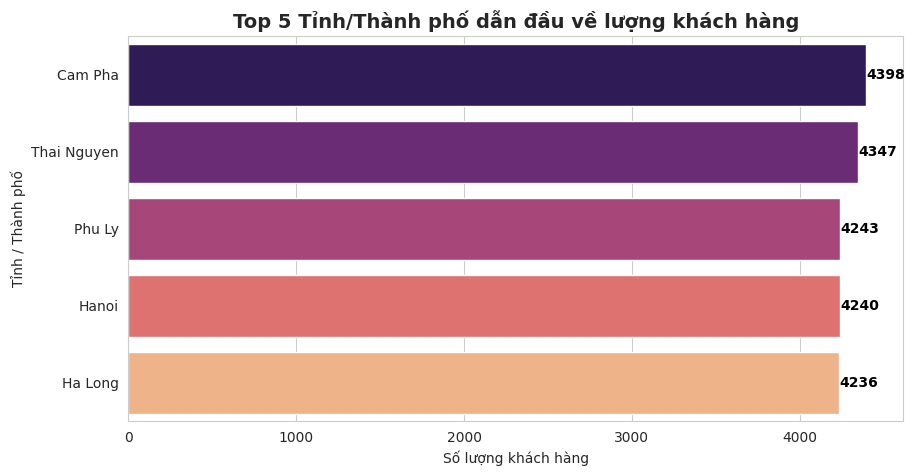

In [34]:
def plot_top_5_provinces(df, province_col='Province'):
    # Lấy dữ liệu top 5
    top_5 = df[province_col].value_counts().nlargest(5)

    # Thiết lập màu sắc và style
    plt.figure(figsize=(10, 5))
    sns.set_style("whitegrid")

    # Vẽ biểu đồ ngang (Horizontal Bar Chart) cho dễ đọc tên tỉnh
    ax = sns.barplot(x=top_5.values, y=top_5.index, palette='magma')

    # Thêm tiêu đề và nhãn
    plt.title('Top 5 Tỉnh/Thành phố dẫn đầu về lượng khách hàng', fontsize=14, fontweight='bold')
    plt.xlabel('Số lượng khách hàng')
    plt.ylabel('Tỉnh / Thành phố')

    # Thêm số liệu vào cuối mỗi thanh
    for i, v in enumerate(top_5.values):
        ax.text(v + 0.5, i, str(v), color='black', va='center', fontweight='bold')

    plt.show()

# Gọi hàm
plot_top_5_provinces(df_customers, province_col='city')

In [35]:
df_orders

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign
...,...,...,...,...,...,...,...,...
646940,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign
646941,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral
646942,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign
646943,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct


In [36]:
# Lọc ra tất cả các dòng mà ID xuất hiện từ 2 lần trở lên
df_duplicate_ids = df_orders[df_orders.duplicated(subset=['customer_id'], keep=False)]

# Sắp xếp lại theo ID để dễ dàng kiểm tra các dòng trùng nhau nằm cạnh nhau
df_duplicate_ids = df_duplicate_ids.sort_values(by='customer_id')

# Hiển thị kết quả
print(f"Tìm thấy {df_duplicate_ids['customer_id'].nunique()} ID bị trùng lặp.")
print(df_duplicate_ids.head())

# 1. Đảm bảo đúng định dạng ngày và sắp xếp theo ID + Thời gian
df_duplicate_ids['order_date'] = pd.to_datetime(df_duplicate_ids['order_date'])
df_duplicate_ids = df_duplicate_ids.sort_values(by=['customer_id', 'order_date'])

# 2. Tính khoảng cách ngày giữa các lần mua của TỪNG khách hàng
# Chúng ta dùng groupby('ID') để tránh tính nhầm khoảng cách giữa khách hàng này và khách hàng kia
df_duplicate_ids['Days_Diff'] = df_duplicate_ids.groupby('customer_id')['order_date'].diff().dt.days

# 3. Tính Trung vị khoảng cách mua hàng cho từng ID
# (Loại bỏ giá trị NaN - lần mua đầu tiên của mỗi người sẽ không có khoảng cách)
df_median_gap = df_duplicate_ids.dropna(subset=['Days_Diff']).groupby('customer_id')['Days_Diff'].median().reset_index()

# Đổi tên cột cho rõ nghĩa
df_median_gap.columns = ['customer_id', 'Median_Purchase_Gap']

print("Bảng trung vị khoảng cách mua hàng của từng ID:")
print(df_median_gap.head())

Tìm thấy 67888 ID bị trùng lặp.
        order_id  order_date  customer_id    zip order_status payment_method  \
374571    483190  2017-04-23            1  15201    delivered            cod   
143252    184922  2014-05-31            1  15201     returned    credit_card   
238890    308113  2015-07-31            1  15201    delivered            cod   
4023        5280  2012-07-25            1  15201    delivered            cod   
544446    702081  2020-02-24            1  15201    delivered    credit_card   

       device_type    order_source  
374571      mobile     paid_search  
143252      mobile        referral  
238890      mobile     paid_search  
4023       desktop     paid_search  
544446      mobile  organic_search  
Bảng trung vị khoảng cách mua hàng của từng ID:
   customer_id  Median_Purchase_Gap
0            1                632.0
1            2                381.0
2            3                168.0
3            5                482.0
4            6                186.0


In [37]:
import pandas as pd
import numpy as np

# Đọc dữ liệu
df_duplicate_ids['order_date'] = pd.to_datetime(df_duplicate_ids['order_date'])

# Sắp xếp và tính khoảng cách
df_duplicate_ids = df_duplicate_ids.sort_values(['order_date'])
df_duplicate_ids['Diff'] = df_duplicate_ids.groupby('customer_id')['order_date'].diff().dt.days

# Lấy trung vị (loại bỏ các giá trị NaN do lần mua đầu)
inter_order_gap_median = df_duplicate_ids['Diff'].median()

print(f"Trung vị khoảng cách giữa các đơn hàng là: {inter_order_gap_median} ngày")

Trung vị khoảng cách giữa các đơn hàng là: 144.0 ngày


In [38]:
df_duplicate_ids[df_duplicate_ids['customer_id'] == 1]

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,Days_Diff,Diff
4023,5280,2012-07-25,1,15201,delivered,cod,desktop,paid_search,NaN,NaN
143252,184922,2014-05-31,1,15201,returned,credit_card,mobile,referral,675.0,675.0
238890,308113,2015-07-31,1,15201,delivered,cod,mobile,paid_search,426.0,426.0
374571,483190,2017-04-23,1,15201,delivered,cod,mobile,paid_search,632.0,632.0
544446,702081,2020-02-24,1,15201,delivered,credit_card,mobile,organic_search,1037.0,1037.0
586950,756884,2021-04-24,1,15201,paid,credit_card,desktop,social_media,425.0,425.0


In [39]:
# 1. Chuyển đổi định dạng ngày tháng
df_duplicate_ids['order_date'] = pd.to_datetime(df_duplicate_ids['order_date'])

# 2. Sắp xếp theo ID trước, sau đó mới đến Ngày (Ascending)
# Việc này đảm bảo các đơn hàng của cùng 1 ID được xếp liên tục và đúng trình tự thời gian
df_duplicate_ids = df_duplicate_ids.sort_values(by=['customer_id', 'order_date'], ascending=True)

# 3. Tính khoảng cách (Diff) giữa các đơn hàng của CÙNG một ID
df_duplicate_ids['Diff'] = df_duplicate_ids.groupby('customer_id')['order_date'].diff().dt.days

# 4. Lấy trung vị (Bỏ qua các giá trị NaN - là các đơn hàng đầu tiên của mỗi ID)
inter_order_gap_median = df_duplicate_ids['Diff'].median()

print(f"Trung vị khoảng cách giữa các đơn hàng là: {inter_order_gap_median} ngày")

Trung vị khoảng cách giữa các đơn hàng là: 144.0 ngày


In [40]:
import pandas as pd

# 1. Tính tỷ suất lợi nhuận cho từng dòng (từng sản phẩm)
# Công thức chuẩn: (Price - COGS) / Price
df_products['profit_rate'] = (df_products['price'] - df_products['cogs']) / df_products['price']

# 2. Nhóm theo loại sản phẩm và tính TRUNG BÌNH CỘNG các tỷ suất
# .groupby('product_type'): gom các dòng cùng loại lại
# ['profit_rate'].mean(): tính trung bình cộng tỷ suất của loại đó
category_avg_profit = df_products.groupby('segment')['profit_rate'].mean().reset_index()

# 3. Tìm giá trị trung bình lớn nhất (Max)
max_avg_profit = category_avg_profit['profit_rate'].max()

# 4. Tìm loại sản phẩm có giá trị Max đó
best_category = category_avg_profit[category_avg_profit['profit_rate'] == max_avg_profit]

print("--- Kết quả tính toán theo loại sản phẩm ---")
print(category_avg_profit)
print("-" * 30)
print(f"Loại sản phẩm có tỷ suất trung bình cao nhất là:")
print(best_category)
print("CÂU TRẢ LỜI LÀ: D")

--- Kết quả tính toán theo loại sản phẩm ---
       segment  profit_rate
0   Activewear     0.265600
1  All-weather     0.284176
2     Balanced     0.258038
3     Everyday     0.236343
4  Performance     0.263650
5      Premium     0.285377
6     Standard     0.313442
7       Trendy     0.240758
------------------------------
Loại sản phẩm có tỷ suất trung bình cao nhất là:
    segment  profit_rate
6  Standard     0.313442
CÂU TRẢ LỜI LÀ: D


In [41]:
df_products

,product_id,product_name,category,segment,size,color,price,cogs,profit_rate
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,0.1225
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,0.4336
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278,0.2871
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954,0.4558
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406,0.1080
...,...,...,...,...,...,...,...,...,...
2407,1260,VietMode MP-28,Casual,Activewear,S,red,4603.340000,2553.933032,0.4452
2408,1261,VietMode MP-29,Casual,Activewear,M,black,5983.876433,4653.660702,0.2223
2409,1262,VietMode MP-30,Casual,Activewear,L,orange,5983.876433,5684.682611,0.0500
2410,1263,VietMode MP-31,Casual,Activewear,XL,blue,5984.370000,5685.151500,0.0500


In [42]:
df_returns

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76
...,...,...,...,...,...,...,...
39934,RET-051470,832867,653,2022-12-27,wrong_size,3,24741.62
39935,RET-051471,832890,792,2022-12-30,late_delivery,1,560.50
39936,RET-051481,833005,449,2022-12-31,defective,1,10002.55
39937,RET-051494,833234,1085,2022-12-28,wrong_size,1,815.57


In [43]:
df_products

,product_id,product_name,category,segment,size,color,price,cogs,profit_rate
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,0.1225
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,0.4336
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278,0.2871
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954,0.4558
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406,0.1080
...,...,...,...,...,...,...,...,...,...
2407,1260,VietMode MP-28,Casual,Activewear,S,red,4603.340000,2553.933032,0.4452
2408,1261,VietMode MP-29,Casual,Activewear,M,black,5983.876433,4653.660702,0.2223
2409,1262,VietMode MP-30,Casual,Activewear,L,orange,5983.876433,5684.682611,0.0500
2410,1263,VietMode MP-31,Casual,Activewear,XL,blue,5984.370000,5685.151500,0.0500


In [44]:
!pip install pandasql
from pandasql import sqldf

# Định nghĩa hàm lambda để gọi cho nhanh
pysql = lambda q: sqldf(q, globals())

query = """
SELECT
p.product_id,
p.category,
r.return_reason
FROM df_products AS p
JOIN df_returns AS r
ON p.product_id = r.product_id
"""

df_returned = pysql(query)
print(df_returned)
category_returned_nums = df_returned.groupby('category')['return_reason'].value_counts().reset_index()
# ... (giữ nguyên phần SQL và tính category_returned_nums bên trên)

# 1. Lọc lấy các dòng thuộc category 'Streetwear'
streetwear_data = category_returned_nums[category_returned_nums['category'] == 'Streetwear']

# 2. Tìm dòng có count (số lượng trả hàng) lớn nhất
# Mặc định cột đếm của value_counts() sau khi reset_index sẽ tên là 'count' (hoặc 'return_reason' tùy bản pandas)
# Ở đây mình dùng idxmax() để lấy index của dòng cao nhất
if not streetwear_data.empty:
    max_row = streetwear_data.loc[streetwear_data['count'].idxmax()]

    reason = max_row['return_reason']
    amount = max_row['count']

    print(f"Lý do trả hàng nhiều nhất của Streetwear là: {reason} ({amount} lượt)")
    print("CÂU TRẢ LỜI: B")
else:
    print("Không có dữ liệu trả hàng cho Streetwear")


  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=9666a0adbe0a2ca20bdc4e0e72deb76a0f7d63258d9eb02d54a9289b1b41cfb7
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql
       product_id    category     return_reason
0             536  Streetwear  not_as_described
1             536  Streetwear        wrong_size
2             537  Streetwear      changed_mind
3             537  Streetwear         defective
4             537  Streetwear         defective
...           ...         ...               ...
39934        1263      Casual      changed_mind
39935        1263      Casual        wrong_size
39936        1264      Casual      changed_mind
39937        1264      Casual      changed_mind
39938        1264      Casual  not_as_described

[39939 rows x 3 columns]
Lý do trả hàng nhiều nhất của Streetwear là: wrong_size (7626 lượt)


In [45]:
print("hello world")

hello world


In [46]:
%cd /content/Datathon_Contest_UITUT

/content/Datathon_Contest_UITUT


In [47]:
%cd /content/Datathon_Contest_UITUT

# 2. Lưu file Notebook hiện tại vào folder này
# (Ông có thể dùng Menu File -> Save, hoặc dùng lệnh copy file nếu ông biết tên file)
# Cách đơn giản nhất: Tạo một file test để kiểm tra GitHub
!touch test_connection.txt

# 3. Đẩy lên lại
from google.colab import userdata
GIT_TOKEN = userdata.get('MY_GITHUB_TOKEN')

!git config --global user.email "email_cua_ong@gmail.com"
!git config --global user.name "lamducanhkhoarubik-spec"

!git add .
!git commit -m "Kiem tra ket noi GitHub"
!git push https://{GIT_TOKEN}@github.com/lamducanhkhoarubik-spec/Datathon_Contest_UITUT.git main

/content/Datathon_Contest_UITUT
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [49]:
import os
from google.colab import userdata

# 1. Cấu hình
GIT_USER = "lamducanhkhoarubik-spec"
GIT_REPO = "Datathon_Contest_UITUT"
GIT_TOKEN = userdata.get('MY_GITHUB_TOKEN')
# Tên file notebook hiện tại (nhìn trên tab trình duyệt)
file_name = "data_analysis.ipynb"

# 2. Lưu file hiện tại vào folder repo
# Lệnh này copy file từ bộ nhớ tạm của Colab vào folder repo đã clone
!cp /content/{file_name} /content/{GIT_REPO}/code/

# 3. Chạy lệnh Push
%cd /content/{GIT_REPO}
!git config --global user.email "lamducanhkhoarubik@gmail.com"
!git config --global user.name "{GIT_USER}"

!git add .
!git commit -m "Push code hien tai"
!git push https://{GIT_TOKEN}@github.com/{GIT_USER}/{GIT_REPO}.git main

print("✅ Đã push xong! Ông lên GitHub F5 là thấy code mới.")

cp: cannot stat '/content/data_analysis.ipynb': No such file or directory
/content/Datathon_Contest_UITUT
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
✅ Đã push xong! Ông lên GitHub F5 là thấy code mới.
